# Bayesian Structural Time Series (BSTS) Counterfactual Analysis
## *Using PyMC with MCMC for Full Posterior Inference*

---

**What would have happened if nothing changed?**

An advertiser suddenly stops investing in display ads. Revenue dips — but how much of that dip is actually *caused* by pulling the ads versus normal market fluctuations?

This notebook implements a **fully Bayesian** version of the structural time series counterfactual analysis, using [PyMC](https://www.pymc.io/) with MCMC (NUTS sampler) for posterior inference.

### How this differs from the OLS version (`bsts_counterfactual.ipynb`)

| | OLS Version | This Notebook (Bayesian) |
|---|---|---|
| **Estimation** | Ordinary Least Squares | PyMC + MCMC / NUTS |
| **Uncertainty** | Prediction intervals from residual variance | Credible intervals from the posterior predictive |
| **Interpretation** | Frequentist: "95% of intervals constructed this way contain the true value" | Bayesian: "95% probability the true value is in this range" |
| **Extra outputs** | — | Full posterior distributions, convergence diagnostics, direct probability statements |

Both versions use the **same structural decomposition** (trend + Fourier seasonality + control regression), the same three spend scenarios, and the same four-check validation suite.

**Reference:** Brodersen, K.H., et al. (2015). [Inferring causal impact using Bayesian structural time series models](https://research.google/pubs/pub41854/). *Annals of Applied Statistics*.

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from scipy import stats

np.random.seed(42)

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 2. Data Simulation

> **Replace this section with your actual data.** The simulation creates a realistic scenario: 104 weeks (2 years) of advertiser sales with trend, seasonality, and a category-level control series. The advertiser stops spending at week 78.

Requirements for real data:
- `weekly_sales`: the treated time series (advertiser sales)
- `category_sales`: a control series sharing market dynamics but unaffected by the intervention
- `intervention_week`: the index where the intervention occurred

In [2]:
n_weeks = 104  # 2 years
t = np.arange(n_weeks)

# Trend
trend = 1000 + 3 * t

# Seasonality (52-week cycle)
seasonality = (80 * np.sin(2 * np.pi * t / 52)
               + 30 * np.cos(2 * np.pi * t / 52)
               + 20 * np.sin(4 * np.pi * t / 52))

# Control series: category-level sales
category_base = 5000 + 8 * t + 200 * np.sin(2 * np.pi * t / 52)
category_noise = np.random.normal(0, 100, n_weeks)
category_sales = category_base + category_noise

# Advertiser sales = trend + seasonality + regression on category + noise
beta_category = 0.15
noise = np.random.normal(0, 40, n_weeks)
advertiser_sales = trend + seasonality + beta_category * category_sales + noise

# Intervention: advertiser stops spending at week 78
intervention_week = 78
spend_effect = np.zeros(n_weeks)
spend_effect[intervention_week:] = -(80 + 2 * np.arange(n_weeks - intervention_week))
advertiser_sales_observed = advertiser_sales + spend_effect

weekly_sales = advertiser_sales_observed.copy()
print(f"Pre-period:  weeks 0-{intervention_week - 1} ({intervention_week} weeks)")
print(f"Post-period: weeks {intervention_week}-{n_weeks - 1} ({n_weeks - intervention_week} weeks)")

Pre-period:  weeks 0-77 (78 weeks)
Post-period: weeks 78-103 (26 weeks)


### Quick look at the data

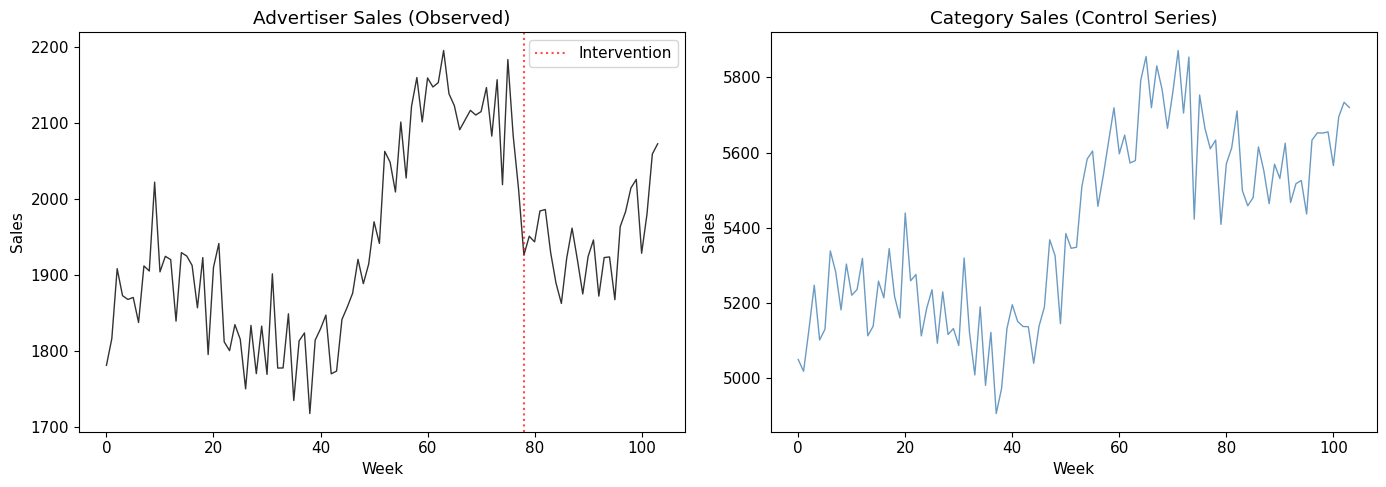

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(t, weekly_sales, 'k-', linewidth=1, alpha=0.8)
axes[0].axvline(intervention_week, color='red', linestyle=':', alpha=0.7, label='Intervention')
axes[0].set_title('Advertiser Sales (Observed)')
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Sales')
axes[0].legend()

axes[1].plot(t, category_sales, 'steelblue', linewidth=1, alpha=0.8)
axes[1].set_title('Category Sales (Control Series)')
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Sales')

plt.tight_layout()
plt.show()

## 3. Feature Construction

The design matrix includes:
- **Linear trend** — captures underlying growth
- **Fourier harmonics** — 3 pairs of sin/cos terms for 52-week seasonality
- **Category sales** — control series regression component

In [4]:
def build_features(t, n_harmonics=3, period=52):
    features = {"trend": t.astype(float)}
    for k in range(1, n_harmonics + 1):
        features[f"sin_{k}"] = np.sin(2 * np.pi * k * t / period)
        features[f"cos_{k}"] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(features)

X = build_features(t)
X["category"] = category_sales

# Split pre/post
pre_idx = t < intervention_week
post_idx = t >= intervention_week

X_pre = X[pre_idx].values
y_pre = weekly_sales[pre_idx]
X_post = X[post_idx].values
y_post = weekly_sales[post_idx]

feature_names = list(X.columns)
n_features = len(feature_names)

print(f"Features: {feature_names}")
print(f"Design matrix shape (pre-period): {X_pre.shape}")

Features: ['trend', 'sin_1', 'cos_1', 'sin_2', 'cos_2', 'sin_3', 'cos_3', 'category']
Design matrix shape (pre-period): (78, 8)


## 4. Bayesian Model (PyMC + MCMC)

This is the core difference from the OLS version. Instead of fitting via least squares, we specify:
- **Priors** on the regression coefficients (weakly informative Normal)
- **Prior** on observation noise (HalfNormal)
- **Likelihood** linking the model to observed data

PyMC uses the NUTS (No-U-Turn Sampler) to draw samples from the posterior distribution.

In [5]:
with pm.Model() as bsts_model:
    # Priors — weakly informative
    beta = pm.Normal("beta", mu=0, sigma=100, shape=n_features)
    alpha = pm.Normal("alpha", mu=np.mean(y_pre), sigma=500)
    sigma = pm.HalfNormal("sigma", sigma=100)

    # Mean function
    mu = alpha + pm.math.dot(X_pre, beta)

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_pre)

    # Sample posterior (4 chains, 2000 draws each after 1000 tuning)
    trace = pm.sample(
        2000, tune=1000, chains=4, cores=1,
        random_seed=42, return_inferencedata=True,
    )

Initializing NUTS using jitter+adapt_diag...
C:\Users\benw3\anaconda3\Lib\site-packages\pytensor\link\c\cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Sequential sampling (4 chains in 1 job)
NUTS: [beta, alpha, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 322 seconds.


### Posterior Summary & Convergence

All R-hat values should be < 1.05 (indicating convergence across chains) and ESS should be > 400.

In [6]:
summary = az.summary(trace, var_names=["alpha", "beta", "sigma"])
print(summary.to_string())
print(f"\nMax R-hat: {float(summary['r_hat'].max()):.3f}")
print(f"Min ESS (bulk): {float(summary['ess_bulk'].min()):.0f}")

             mean       sd   hdi_3%   hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
alpha    1033.310  235.480  600.115  1485.564      4.770    3.215    2434.0    3417.0    1.0
beta[0]     3.165    0.459    2.303     4.044      0.009    0.006    2690.0    3928.0    1.0
beta[1]    88.792   12.368   64.884   111.562      0.234    0.151    2780.0    3988.0    1.0
beta[2]    33.458    7.128   19.716    46.453      0.090    0.078    6316.0    5434.0    1.0
beta[3]    19.294    7.383    5.230    32.888      0.100    0.077    5475.0    5697.0    1.0
beta[4]     0.571    7.041  -12.445    13.978      0.090    0.076    6150.0    5813.0    1.0
beta[5]     4.135    7.000   -8.945    17.338      0.085    0.079    6802.0    5541.0    1.0
beta[6]     3.176    6.993   -9.676    16.688      0.093    0.090    5666.0    4900.0    1.0
beta[7]     0.143    0.047    0.052     0.230      0.001    0.001    2413.0    3413.0    1.0
sigma      41.990    3.753   35.010    48.954      0.056    0.051    4

## 5. Counterfactual Projection

Using the posterior samples, we project what sales *would have been* in the post-period had the advertiser continued spending. Each posterior sample generates a different counterfactual trajectory, and the ensemble gives us **credible intervals** — genuine probability statements about the range of the true counterfactual.

In [7]:
# Extract posterior samples
alpha_samples = trace.posterior["alpha"].values.reshape(-1)
beta_samples = trace.posterior["beta"].values.reshape(-1, n_features)
sigma_samples = trace.posterior["sigma"].values.reshape(-1)
n_samples = len(alpha_samples)

# Generate counterfactual for full time series
X_full = X.values
cf_samples = np.zeros((n_samples, n_weeks))
for i in range(n_samples):
    mu_i = alpha_samples[i] + X_full @ beta_samples[i]
    cf_samples[i] = mu_i + np.random.normal(0, sigma_samples[i], n_weeks)

cf_mean = cf_samples.mean(axis=0)
cf_lower = np.percentile(cf_samples, 2.5, axis=0)
cf_upper = np.percentile(cf_samples, 97.5, axis=0)

# Causal impact
post_cf = cf_mean[post_idx]
post_actual = y_post
point_impact = post_actual - post_cf

print(f"Posterior samples: {n_samples}")
print(f"Mean weekly causal impact: {point_impact.mean():+.1f}")
print(f"Cumulative impact: {np.cumsum(point_impact)[-1]:+.1f}")
print(f"Relative effect: {(point_impact.mean() / post_cf.mean()) * 100:+.1f}%")

Posterior samples: 8000
Mean weekly causal impact: -111.2
Cumulative impact: -2891.1
Relative effect: -5.4%


### Counterfactual vs. Observed

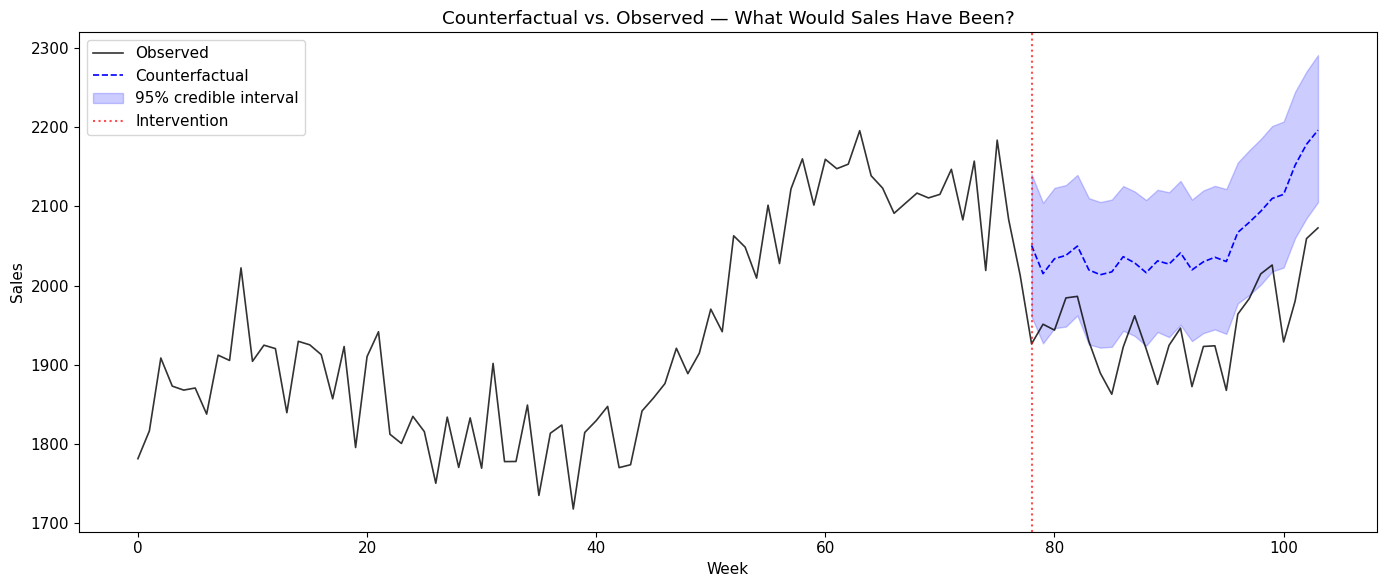

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(t, weekly_sales, 'k-', linewidth=1.2, label='Observed', alpha=0.8)
ax.plot(t[post_idx], cf_mean[post_idx], 'b--', linewidth=1.2, label='Counterfactual')
ax.fill_between(t[post_idx], cf_lower[post_idx], cf_upper[post_idx],
                alpha=0.2, color='blue', label='95% credible interval')
ax.axvline(intervention_week, color='red', linestyle=':', alpha=0.7, label='Intervention')
ax.set_title('Counterfactual vs. Observed — What Would Sales Have Been?')
ax.set_xlabel('Week')
ax.set_ylabel('Sales')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Three Spend Scenarios

Rather than a single counterfactual, we model three investment levels to give decision-makers a **menu of options**:

| Scenario | Description |
|----------|-------------|
| A: 50% Spend | Conservative re-entry |
| B: 100% Spend | Full restoration |
| C: 150% Spend | Growth investment |

Each scenario gets its own credible intervals from the posterior.

In [9]:
scenarios = {
    "A: 50% Spend":  0.50,
    "B: 100% Spend": 1.00,
    "C: 150% Spend": 1.50,
}

baseline_gap = post_cf - post_actual
scenario_results = {}

for name, multiplier in scenarios.items():
    scenario_cf = np.zeros((n_samples, post_idx.sum()))
    for i in range(n_samples):
        mu_i = alpha_samples[i] + X_post @ beta_samples[i]
        noise_i = np.random.normal(0, sigma_samples[i], post_idx.sum())
        full_cf_i = mu_i + noise_i
        gap_i = full_cf_i - post_actual
        scenario_cf[i] = post_actual + gap_i * multiplier

    scenario_mean = scenario_cf.mean(axis=0)
    scenario_lower = np.percentile(scenario_cf, 2.5, axis=0)
    scenario_upper = np.percentile(scenario_cf, 97.5, axis=0)
    uplift = ((scenario_mean.mean() - post_actual.mean()) / post_actual.mean()) * 100

    scenario_results[name] = {
        "mean": scenario_mean, "lower": scenario_lower,
        "upper": scenario_upper, "uplift": uplift,
    }
    print(f"{name}: {uplift:+.1f}% weekly uplift")

A: 50% Spend: +2.8% weekly uplift
B: 100% Spend: +5.7% weekly uplift
C: 150% Spend: +8.6% weekly uplift


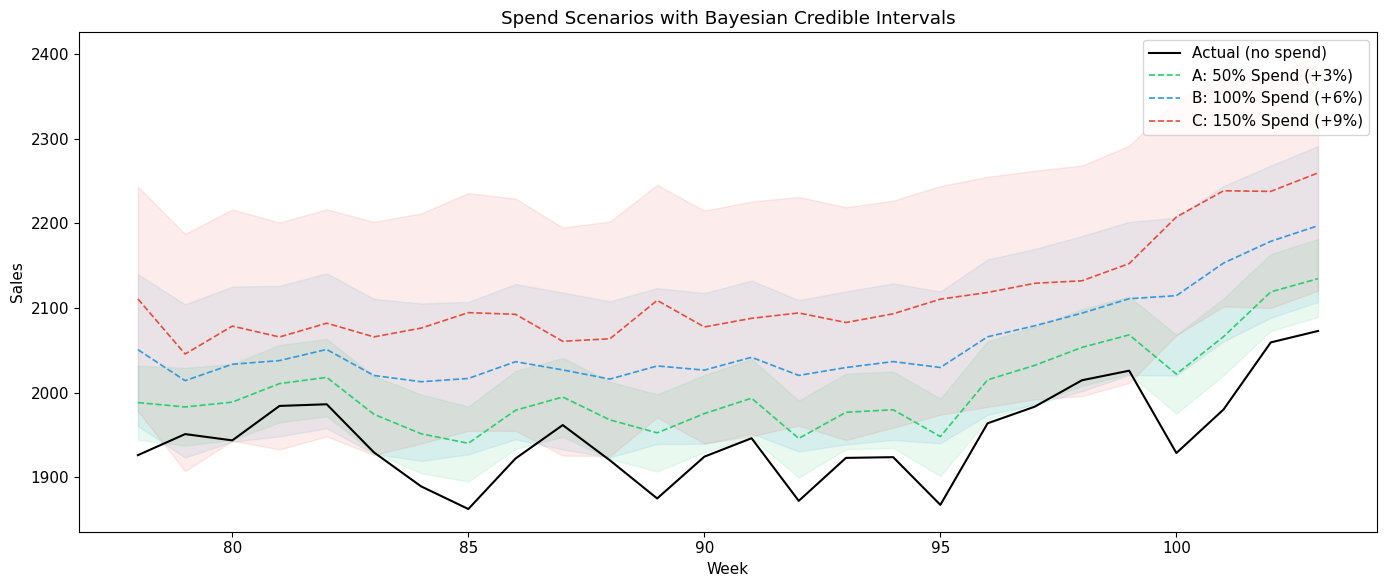

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(t[post_idx], post_actual, 'k-', linewidth=1.5, label='Actual (no spend)')
colors = ['#2ecc71', '#3498db', '#e74c3c']
for (name, result), color in zip(scenario_results.items(), colors):
    ax.plot(t[post_idx], result['mean'], '--', color=color, linewidth=1.2,
            label=f'{name} ({result["uplift"]:+.0f}%)')
    ax.fill_between(t[post_idx], result['lower'], result['upper'],
                    alpha=0.1, color=color)
ax.set_title('Spend Scenarios with Bayesian Credible Intervals')
ax.set_xlabel('Week')
ax.set_ylabel('Sales')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Validation Suite

The same four checks as the OLS version, ensuring the counterfactual is trustworthy:

1. **Pre-period MAPE** — can the model predict what already happened?
2. **Credible interval calibration** — do the 95% intervals actually contain ~95% of observations?
3. **Residual diagnostics** — any systematic patterns in prediction errors?
4. **Placebo test** — does the model find a spurious effect where none exists?

In [11]:
pre_fitted = cf_mean[pre_idx]
pre_residuals = y_pre - pre_fitted

# 1. Pre-period MAPE
mape = np.mean(np.abs(pre_residuals) / np.abs(y_pre)) * 100
print(f"1. Pre-period MAPE: {mape:.2f}%")

# 2. Credible interval calibration
pre_cf_samples = cf_samples[:, pre_idx]
pre_lower = np.percentile(pre_cf_samples, 2.5, axis=0)
pre_upper = np.percentile(pre_cf_samples, 97.5, axis=0)
coverage = np.mean((y_pre >= pre_lower) & (y_pre <= pre_upper)) * 100
print(f"2. 95% credible interval coverage: {coverage:.1f}%")

# 3. Residual diagnostics
shapiro_stat, shapiro_p = stats.shapiro(pre_residuals[:50])
dw_stat = np.sum(np.diff(pre_residuals) ** 2) / np.sum(pre_residuals ** 2)
print(f"3. Residual diagnostics:")
print(f"   Shapiro-Wilk p-value: {shapiro_p:.4f} ({'normal' if shapiro_p > 0.05 else 'non-normal'})")
print(f"   Durbin-Watson: {dw_stat:.2f} (target ~2.0)")

1. Pre-period MAPE: 1.59%
2. 95% credible interval coverage: 97.4%
3. Residual diagnostics:
   Shapiro-Wilk p-value: 0.8092 (normal)
   Durbin-Watson: 2.38 (target ~2.0)


### Placebo Test

Fit the same model on category-level sales — which are **known to be unaffected** by the intervention — and verify it detects no spurious effect. If the model "finds" an effect where none exists, the methodology is broken.

In [12]:
print("Fitting placebo model on control series...")

# Exclude 'category' column since category_sales is the target
X_pre_placebo = X_pre[:, :-1]
X_post_placebo = X_post[:, :-1]
n_features_placebo = n_features - 1

with pm.Model() as placebo_model:
    beta_p = pm.Normal("beta_p", mu=0, sigma=100, shape=n_features_placebo)
    alpha_p = pm.Normal("alpha_p", mu=np.mean(category_sales[pre_idx]), sigma=500)
    sigma_p = pm.HalfNormal("sigma_p", sigma=100)

    mu_p = alpha_p + pm.math.dot(X_pre_placebo, beta_p)
    y_obs_p = pm.Normal("y_obs_p", mu=mu_p, sigma=sigma_p,
                        observed=category_sales[pre_idx])

    trace_p = pm.sample(
        1000, tune=500, chains=4, cores=1,
        target_accept=0.95, random_seed=43,
        return_inferencedata=True,
    )

alpha_p_samples = trace_p.posterior["alpha_p"].values.reshape(-1)
beta_p_samples = trace_p.posterior["beta_p"].values.reshape(-1, n_features_placebo)
sigma_p_samples = trace_p.posterior["sigma_p"].values.reshape(-1)

placebo_cf = np.zeros((len(alpha_p_samples), post_idx.sum()))
for i in range(len(alpha_p_samples)):
    mu_i = alpha_p_samples[i] + X_post_placebo @ beta_p_samples[i]
    placebo_cf[i] = mu_i + np.random.normal(0, sigma_p_samples[i], post_idx.sum())

placebo_mean = placebo_cf.mean(axis=0)
placebo_impact = category_sales[post_idx] - placebo_mean
placebo_relative = (placebo_impact.mean() / placebo_mean.mean()) * 100

print(f"\n4. Placebo relative effect: {placebo_relative:+.2f}% (should be ~0%)")
if abs(placebo_relative) < 3:
    print("   ✓ No spurious effect detected — methodology is sound")
else:
    print("   ⚠ Possible spurious effect — review control series")

Fitting placebo model on control series...


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [beta_p, alpha_p, sigma_p]


Output()

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 27 seconds.



4. Placebo relative effect: -0.41% (should be ~0%)
   ✓ No spurious effect detected — methodology is sound


### Validation Plots

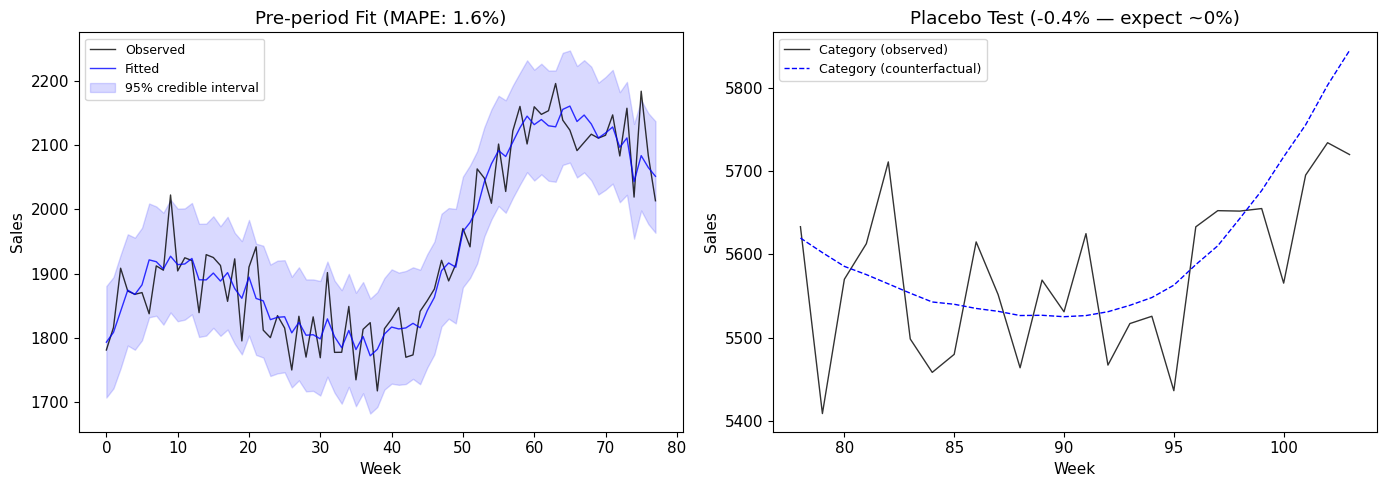

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pre-period fit
ax = axes[0]
ax.plot(t[pre_idx], y_pre, 'k-', linewidth=1, label='Observed', alpha=0.8)
ax.plot(t[pre_idx], pre_fitted, 'b-', linewidth=1, label='Fitted', alpha=0.8)
ax.fill_between(t[pre_idx], pre_lower, pre_upper,
                alpha=0.15, color='blue', label='95% credible interval')
ax.set_title(f'Pre-period Fit (MAPE: {mape:.1f}%)')
ax.set_xlabel('Week')
ax.set_ylabel('Sales')
ax.legend(fontsize=9)

# Placebo
ax = axes[1]
ax.plot(t[post_idx], category_sales[post_idx], 'k-', linewidth=1,
        label='Category (observed)', alpha=0.8)
ax.plot(t[post_idx], placebo_mean, 'b--', linewidth=1,
        label='Category (counterfactual)')
ax.set_title(f'Placebo Test ({placebo_relative:+.1f}% — expect ~0%)')
ax.set_xlabel('Week')
ax.set_ylabel('Sales')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 8. Posterior Diagnostics

These are **unique to the Bayesian version** and provide confidence that the MCMC sampler has converged and the posterior is well-estimated.

C:\Users\benw3\AppData\Local\Temp\ipykernel_35372\2385498908.py:27: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for chain in range(trace.posterior.dims["chain"]):


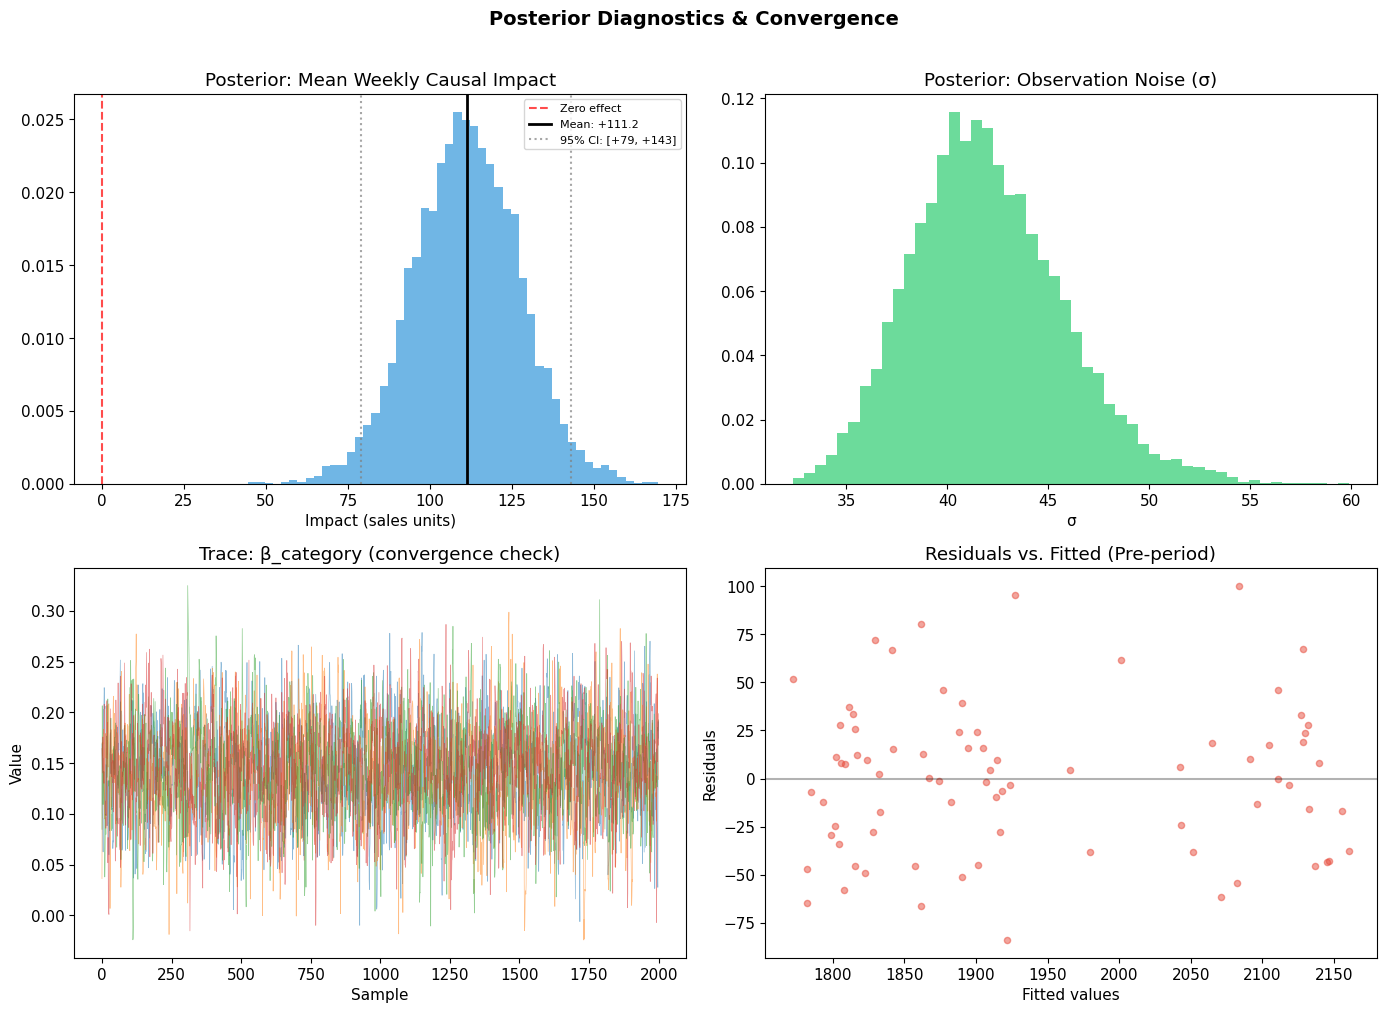

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Posterior of causal impact
post_impact_samples = cf_samples[:, post_idx].mean(axis=1) - post_actual.mean()
ax = axes[0, 0]
ax.hist(post_impact_samples, bins=50, density=True, alpha=0.7, color='#3498db')
ax.axvline(0, color='red', linestyle='--', alpha=0.7, label='Zero effect')
ax.axvline(post_impact_samples.mean(), color='black', linestyle='-', linewidth=2,
           label=f'Mean: {post_impact_samples.mean():+.1f}')
ci_low, ci_high = np.percentile(post_impact_samples, [2.5, 97.5])
ax.axvline(ci_low, color='gray', linestyle=':', alpha=0.7)
ax.axvline(ci_high, color='gray', linestyle=':', alpha=0.7,
           label=f'95% CI: [{ci_low:+.0f}, {ci_high:+.0f}]')
ax.set_title('Posterior: Mean Weekly Causal Impact')
ax.set_xlabel('Impact (sales units)')
ax.legend(fontsize=8)

# Posterior of sigma
ax = axes[0, 1]
ax.hist(sigma_samples, bins=50, density=True, alpha=0.7, color='#2ecc71')
ax.set_title('Posterior: Observation Noise (σ)')
ax.set_xlabel('σ')

# Trace plot
category_idx = feature_names.index("category")
ax = axes[1, 0]
for chain in range(trace.posterior.dims["chain"]):
    chain_samples = trace.posterior["beta"].values[chain, :, category_idx]
    ax.plot(chain_samples, alpha=0.5, linewidth=0.5)
ax.set_title('Trace: β_category (convergence check)')
ax.set_xlabel('Sample')
ax.set_ylabel('Value')

# Residuals vs fitted
ax = axes[1, 1]
ax.scatter(pre_fitted, pre_residuals, alpha=0.5, s=20, color='#e74c3c')
ax.axhline(0, color='black', linestyle='-', alpha=0.3)
ax.set_title('Residuals vs. Fitted (Pre-period)')
ax.set_xlabel('Fitted values')
ax.set_ylabel('Residuals')

plt.suptitle('Posterior Diagnostics & Convergence', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Bayesian Inference — Direct Probability Statements

This is the payoff of the Bayesian approach. Instead of a p-value or a confidence interval, we can make **direct probability statements** about the causal effect:

In [15]:
prob_negative = np.mean(post_impact_samples < 0) * 100

print("=" * 60)
print("BAYESIAN CAUSAL INFERENCE")
print("=" * 60)
print(f"\nPosterior probability that stopping spend")
print(f"REDUCED sales: {prob_negative:.1f}%")
print(f"\n95% credible interval for weekly impact:")
print(f"  [{ci_low:+.1f}, {ci_high:+.1f}]")
print(f"\nInterpretation: There is a {100-prob_negative:.0f}% probability")
print(f"that the true revenue left on the table is between")
print(f"{abs(ci_high):.0f} and {abs(ci_low):.0f} per week.")
print(f"\nThis is a DIRECT probability statement about the")
print(f"parameter — not a statement about repeated sampling.")
print("=" * 60)

BAYESIAN CAUSAL INFERENCE

Posterior probability that stopping spend
REDUCED sales: 0.0%

95% credible interval for weekly impact:
  [+79.0, +143.0]

Interpretation: There is a 100% probability
that the true revenue left on the table is between
143 and 79 per week.

This is a DIRECT probability statement about the
parameter — not a statement about repeated sampling.


---

## Key Takeaways

**The Bayesian version adds three things the OLS version cannot provide:**

1. **Direct probability statements.** "There is a 95% probability the true impact is between X and Y" — this is what decision-makers actually want to hear, and it's only valid with Bayesian credible intervals, not frequentist confidence intervals.

2. **Full posterior distributions.** Instead of a single point estimate of each coefficient, you get a distribution. This lets you see how uncertain the model is about each component (trend, seasonality, category relationship).

3. **Convergence diagnostics.** R-hat and effective sample size tell you whether the MCMC sampler has explored the posterior adequately. If R-hat > 1.05 or ESS is low, you know not to trust the results — a self-diagnostic that OLS doesn't offer.

**The structural decomposition is identical.** The Bayesian machinery is the estimation layer — it doesn't change what the model decomposes (trend, seasonality, control regression), it changes how the parameters are estimated and how uncertainty is quantified.

**Reference:** Brodersen, K.H., et al. (2015). [Inferring causal impact using Bayesian structural time series models](https://research.google/pubs/pub41854/). *Annals of Applied Statistics*.